# 🦈 Shark Tank India — ML Pipeline
### Three-Stage Prediction:
1. **Objective 1** — Will the startup get funded? (Binary Classification)
2. **Objective 2** — Which sharks will invest? (Multi-Output Classification) — *Only if funded*
3. **Objective 3** — How much funding will they get? (Regression) — *Uses shark predictions as input*

---
**Flow:** Baseline → Optuna Hyperparameter Tuning for all models

## 📦 0. Install Dependencies

In [1]:
# Run this cell once to install required packages
import subprocess, sys

packages = [
    'scikit-learn', 'xgboost', 'lightgbm', 'optuna',
    'pandas', 'numpy', 'matplotlib', 'seaborn',
    'torch', 'torchvision'
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All packages installed.')

✅ All packages installed.


## 📚 1. Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    mean_squared_error, mean_absolute_error, r2_score,
    hamming_loss
)
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import DBSCAN
from xgboost import XGBClassifier
import lightgbm as lgb

# Regressors
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# ANN
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print('✅ All imports successful.')

✅ All imports successful.


## 🔧 2. Preprocessing Pipeline
*Paste your preprocessing.py file path below or keep it inline*

In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

def run_preprocessing(df: pd.DataFrame):
    """
    Final preprocessing pipeline for shark tank data.
    Returns:
        X_scaled : Processed feature matrix (DataFrame)
        y_reg    : Regression target (Total Deal Amount)
        y_cls    : Classification target (Accepted Offer)
        y_shark  : Multi-label target (Individual shark investments)

    NaN handling summary:
        - shark_amt_cols      : fillna(0) — no investment means 0
        - shark_present_cols  : fillna(0) — not present means 0
        - financial_cols/ask_cols : to_numeric + fillna(median)
        - pitcher_cols (numeric): to_numeric + fillna(median)
        - Pitchers Average Age : categorical ('Young'/'Middle'/'Old'),
                                  label-encoded then NaN filled with mode
        - Cash Burn           : binary string ('yes'), converted to 0/1
                                  then NaN filled with 0
        - Started in          : numeric year, fillna(median)
        - Industry            : NaN rows get all-zero dummy columns (safe)
    """
    df = df.copy()

    shark_amt_cols = [
        'Namita Investment Amount', 'Vineeta Investment Amount',
        'Anupam Investment Amount', 'Aman Investment Amount',
        'Peyush Investment Amount', 'Ritesh Investment Amount',
        'Amit Investment Amount'
    ]
    shark_present_cols = [
        'Namita Present', 'Vineeta Present', 'Anupam Present',
        'Aman Present', 'Peyush Present', 'Ritesh Present',
        'Amit Present', 'Guest Present'
    ]

    # ── Shark amounts & presence ─────────────────────────────────────────────
    df[shark_amt_cols]     = df[shark_amt_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    df[shark_present_cols] = df[shark_present_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    df['sharks_present_count'] = df[shark_present_cols].sum(axis=1)

    y_shark = (df[shark_amt_cols] > 0).astype(int)
    y_shark.columns = [
        'Namita_Invested', 'Vineeta_Invested', 'Anupam_Invested',
        'Aman_Invested', 'Peyush_Invested', 'Ritesh_Invested', 'Amit_Invested'
    ]

    # ── Derived targets ──────────────────────────────────────────────────────
    df['Total Deal Amount']       = df[shark_amt_cols].sum(axis=1)
    df['Number of Sharks in Deal'] = (df[shark_amt_cols] > 0).sum(axis=1)

    # ── Financial & ask columns (numeric) ───────────────────────────────────
    financial_cols = ['Yearly Revenue', 'Monthly Sales', 'Gross Margin',
                      'Net Margin', 'EBITDA', 'SKUs']
    ask_cols       = ['Original Ask Amount', 'Original Offered Equity', 'Valuation Requested']

    num_cols = financial_cols + ask_cols
    df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())

    # ── Cash Burn: binary string column ('yes' / NaN) ───────────────────────
    # Convert to 1/0; NaN (no data) treated as 0 (not burning cash / unknown)
    df['Cash Burn'] = df['Cash Burn'].apply(
        lambda x: 1 if str(x).strip().lower() == 'yes' else 0
    )

    # ── Accepted Offer ───────────────────────────────────────────────────────
    df['Accepted Offer']          = df['Accepted Offer'].fillna(0).astype(int)
    df['Original Offered Equity'] = df['Original Offered Equity'].replace(0, 1e-6)
    df['Original Ask Amount']     = df['Original Ask Amount'].replace(0, 1e-6)

    # ── Engineered financial ratios ──────────────────────────────────────────
    df['ask_per_equity']      = df['Original Ask Amount'] / df['Original Offered Equity']
    df['valuation_ask_ratio'] = df['Valuation Requested']  / df['Original Ask Amount']
    df['revenue_ask_ratio']   = df['Yearly Revenue']       / df['Original Ask Amount']
    df['is_revenue_positive'] = (df['Yearly Revenue'] > 0).astype(int)

    y_reg = df['Total Deal Amount']
    y_cls = df['Accepted Offer']

    # ── Context columns ──────────────────────────────────────────────────────
    context_cols = ['Season Number', 'Season Start', 'Season End', 'Started in', 'Industry']

    # 'Started in': numeric year — fill missing with median year
    df['Started in'] = pd.to_numeric(df['Started in'], errors='coerce')
    df['Started in'] = df['Started in'].fillna(df['Started in'].median())

    # ── Pitcher columns ──────────────────────────────────────────────────────
    numeric_pitcher_cols = [
        'Number of Presenters', 'Male Presenters', 'Female Presenters',
        'Transgender Presenters', 'Couple Presenters'
    ]
    gender_cols = ['Male Presenters', 'Female Presenters',
                   'Transgender Presenters', 'Couple Presenters']

    df[numeric_pitcher_cols] = df[numeric_pitcher_cols].apply(pd.to_numeric, errors='coerce')
    df[numeric_pitcher_cols] = df[numeric_pitcher_cols].fillna(df[numeric_pitcher_cols].median())

    # 'Pitchers Average Age': categorical string ('Young' / 'Middle' / 'Old')
    # Label-encode: Young=0, Middle=1, Old=2; NaN → mode
    age_map = {'Young': 0, 'Middle': 1, 'Old': 2}
    df['Pitchers Average Age'] = df['Pitchers Average Age'].map(age_map)
    age_mode = df['Pitchers Average Age'].mode(dropna=True)
    df['Pitchers Average Age'] = df['Pitchers Average Age'].fillna(
        age_mode[0] if len(age_mode) > 0 else 1  # default to 'Middle' if no mode
    )

    pitcher_cols = numeric_pitcher_cols + ['Pitchers Average Age']

    # ── Engineered pitcher features ──────────────────────────────────────────
    df['team_gender_diversity'] = (
        (df[gender_cols] > 0).sum(axis=1) / df['Number of Presenters'].replace(0, 1)
    )
    df['season_number_norm'] = (
        (df['Season Number'] - df['Season Number'].min()) /
        (df['Season Number'].max() - df['Season Number'].min())
    )

    # ── Assemble feature matrix ──────────────────────────────────────────────
    X = pd.concat([
        df[context_cols + pitcher_cols + ['team_gender_diversity', 'season_number_norm']],
        df[financial_cols + ['Cash Burn'] + ask_cols + [
            'ask_per_equity', 'valuation_ask_ratio', 'revenue_ask_ratio',
            'is_revenue_positive', 'Number of Sharks in Deal'
        ]],
        df[shark_amt_cols + shark_present_cols + ['sharks_present_count']]
    ], axis=1)

    # Industry: get_dummies handles NaN rows as all-zero (safe)
    X = pd.get_dummies(X, columns=['Industry'], drop_first=True)
    X = X.drop(['Season Start', 'Season End'], axis=1, errors='ignore')

    # Final NaN check — should be zero
    remaining_nans = X.isnull().sum().sum()
    if remaining_nans > 0:
        print(f"⚠️  Warning: {remaining_nans} NaN values remain in X. Filling with column medians.")
        X = X.fillna(X.median(numeric_only=True))

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

    return X_scaled, y_reg, y_cls, y_shark


## 📂 3. Load Data & Preprocess

In [4]:
# ── Update this path to your dataset ────────────────────────────────────────
DATA_PATH = '/home/varnan/Works/Projects/Shark-tank-India-Decision-Modeling/Shark Tank India.csv'   # <-- change this

raw_df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {raw_df.shape}')
raw_df.head(3)

Dataset shape: (789, 80)


,Season Number,Startup Name,Episode Number,Pitch Number,Season Start,Season End,Original Air Date,Episode Title,Anchor,Industry,...,Invested Guest Name,All Guest Names,Namita Present,Vineeta Present,Anupam Present,Aman Present,Peyush Present,Ritesh Present,Amit Present,Guest Present
0,1,BluePineFoods,1,1,20-Dec-21,4-Feb-22,20-Dec-21,Badlegi Business Ki Tasveer,Rannvijay Singh,Food and Beverage,...,Ashneer Grover,Ashneer Grover,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0
1,1,BoozScooters,1,2,20-Dec-21,4-Feb-22,20-Dec-21,Badlegi Business Ki Tasveer,Rannvijay Singh,Vehicles/Electrical Vehicles,...,Ashneer Grover,Ashneer Grover,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0
2,1,HeartUpMySleeves,1,3,20-Dec-21,4-Feb-22,20-Dec-21,Badlegi Business Ki Tasveer,Rannvijay Singh,Beauty/Fashion,...,NaN,Ashneer Grover,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0


In [5]:
# ── Remove logical fallacy: funded but no shark invested ─────────────────────
shark_amt_cols = [
    'Namita Investment Amount', 'Vineeta Investment Amount',
    'Anupam Investment Amount', 'Aman Investment Amount',
    'Peyush Investment Amount', 'Ritesh Investment Amount',
    'Amit Investment Amount'
]
fallacy_mask = (raw_df['Accepted Offer'] == 1) & ((raw_df[shark_amt_cols].apply(pd.to_numeric, errors='coerce').fillna(0) > 0).sum(axis=1) == 0)
raw_df = raw_df[~fallacy_mask].reset_index(drop=True)
print(f"Removed {fallacy_mask.sum()} logically inconsistent rows from raw_df.")

Removed 31 logically inconsistent rows from raw_df.


In [6]:
X_scaled, y_reg, y_cls, y_shark = run_preprocessing(raw_df)

print(f'X shape      : {X_scaled.shape}')
print(f'y_cls dist   : {y_cls.value_counts().to_dict()}  (0=No Deal, 1=Deal)')
print(f'y_reg range  : {y_reg.min():.0f} – {y_reg.max():.0f}')
print(f'y_shark shape: {y_shark.shape}')
y_shark.sum().rename('investments_count')

X shape      : (758, 58)
y_cls dist   : {1: 403, 0: 355}  (0=No Deal, 1=Deal)
y_reg range  : 0 – 500
y_shark shape: (758, 7)


Namita_Invested     135
Vineeta_Invested     95
Anupam_Invested     117
Aman_Invested       162
Peyush_Invested     103
Ritesh_Invested      59
Amit_Invested        38
Name: investments_count, dtype: int64

In [7]:
pd.set_option("display.max_columns", None)

In [8]:
X_scaled.info()

<class 'pandas.DataFrame'>
RangeIndex: 758 entries, 0 to 757
Data columns (total 58 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Season Number                          758 non-null    float64
 1   Started in                             758 non-null    float64
 2   Number of Presenters                   758 non-null    float64
 3   Male Presenters                        758 non-null    float64
 4   Female Presenters                      758 non-null    float64
 5   Transgender Presenters                 758 non-null    float64
 6   Couple Presenters                      758 non-null    float64
 7   Pitchers Average Age                   758 non-null    float64
 8   team_gender_diversity                  758 non-null    float64
 9   season_number_norm                     758 non-null    float64
 10  Yearly Revenue                         758 non-null    float64
 11  Monthly Sales    

In [9]:
X_scaled.drop("Namita Investment Amount", axis = 1, inplace = True)
X_scaled.drop("Vineeta Investment Amount", axis = 1, inplace = True)
X_scaled.drop("Anupam Investment Amount", axis = 1, inplace = True)
X_scaled.drop("Aman Investment Amount", axis = 1, inplace = True)
X_scaled.drop("Peyush Investment Amount", axis = 1, inplace = True)
X_scaled.drop("Ritesh Investment Amount", axis = 1, inplace = True)
X_scaled.drop("Amit Investment Amount", axis = 1, inplace = True)
X_scaled.drop("Number of Sharks in Deal", axis = 1, inplace = True)

## 🔪 4. Train/Test Splits

In [10]:
RANDOM_STATE = 42
TEST_SIZE    = 0.2

# ── Obj 1: Binary classification split ──────────────────────────────────────
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_scaled, y_cls, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_cls
)

# ── Obj 2: Multi-label split (funded pitches only) ───────────────────────────
funded_mask       = (y_cls == 1)
X_funded          = X_scaled[funded_mask].reset_index(drop=True)
y_shark_funded    = y_shark[funded_mask].reset_index(drop=True)

X_train_shark, X_test_shark, y_train_shark, y_test_shark = train_test_split(
    X_funded, y_shark_funded, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# ── Obj 3: Regression split (funded pitches only) ────────────────────────────
y_reg_funded = y_reg[funded_mask].reset_index(drop=True)

# Augment features with shark binary predictions (use truth labels at train time)
X_reg_aug = pd.concat([
    X_funded.reset_index(drop=True),
    y_shark_funded.reset_index(drop=True)
], axis=1)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_aug, y_reg_funded, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f'Obj1 — train: {X_train_cls.shape}, test: {X_test_cls.shape}')
print(f'Obj2 — train: {X_train_shark.shape}, test: {X_test_shark.shape}')
print(f'Obj3 — train: {X_train_reg.shape}, test: {X_test_reg.shape}')

Obj1 — train: (606, 50), test: (152, 50)
Obj2 — train: (322, 50), test: (81, 50)
Obj3 — train: (322, 57), test: (81, 57)


## 🧠 5. ANN Definitions (PyTorch)

In [11]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── Generic MLP ─────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, dropout=0.3, task='binary'):
        super().__init__()
        self.task = task
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, output_dim))
        if task == 'binary':   layers.append(nn.Sigmoid())
        if task == 'multilabel': layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_ann(model, X_tr, y_tr, epochs=50, lr=1e-3, batch_size=32, task='binary',
              patience=15, val_split=0.15):
    """Train ANN with early stopping based on validation loss.

    Args:
        patience:   Number of epochs with no improvement before stopping.
        val_split:  Fraction of training data held out for early-stopping validation.
                    Set to 0 to disable early stopping.
    """
    model.to(DEVICE)
    X_arr = X_tr.values if hasattr(X_tr, 'values') else X_tr
    y_arr = y_tr.values if hasattr(y_tr, 'values') else y_tr

    # ── Optional validation split for early stopping ─────────────────────────
    if val_split > 0 and len(X_arr) > 10:
        split_idx = max(1, int(len(X_arr) * (1 - val_split)))
        X_train_es, X_val_es = X_arr[:split_idx], X_arr[split_idx:]
        y_train_es, y_val_es = y_arr[:split_idx], y_arr[split_idx:]
    else:
        X_train_es, y_train_es = X_arr, y_arr
        X_val_es, y_val_es = None, None

    def to_tensor(X, y):
        Xt = torch.FloatTensor(X).to(DEVICE)
        yt = torch.FloatTensor(y).to(DEVICE)
        if task in ('binary', 'regression'):
            yt = yt.unsqueeze(1)
        return Xt, yt

    X_t, y_t = to_tensor(X_train_es, y_train_es)
    criterion = nn.BCELoss() if task in ('binary', 'multilabel') else nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    dataset   = TensorDataset(X_t, y_t)
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    best_val_loss = float('inf')
    best_state    = None
    no_improve    = 0

    model.train()
    for epoch in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        # ── Early stopping check ─────────────────────────────────────────────
        if X_val_es is not None:
            model.eval()
            with torch.no_grad():
                Xv, yv = to_tensor(X_val_es, y_val_es)
                val_loss = criterion(model(Xv), yv).item()
            model.train()

            if val_loss < best_val_loss - 1e-6:
                best_val_loss = val_loss
                best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                no_improve    = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    break  # early stop

    # Restore best weights if early stopping was active
    if best_state is not None:
        model.load_state_dict(best_state)
    return model


def predict_ann(model, X_te, task='binary', threshold=0.5):
    model.eval()
    X_t = torch.FloatTensor(X_te.values if hasattr(X_te, 'values') else X_te).to(DEVICE)
    with torch.no_grad():
        out = model(X_t).cpu().numpy()
    if task == 'regression':
        return out.squeeze()
    return (out >= threshold).astype(int)


Using device: cuda


## 📊 6. Metric Helpers

In [12]:
def cls_metrics(y_true, y_pred, label=''):
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_pred)
    except Exception:
        auc = float('nan')
    print(f'  {label:<30} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}')
    return {'model': label, 'accuracy': acc, 'f1': f1, 'auc': auc}


def reg_metrics(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'  {label:<30} RMSE={rmse:.2f}  MAE={mae:.2f}  R2={r2:.4f}')
    return {'model': label, 'rmse': rmse, 'mae': mae, 'r2': r2}


def multilabel_metrics(y_true, y_pred, label=''):
    hl   = hamming_loss(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='samples', zero_division=0)
    f1m  = f1_score(y_true, y_pred, average='macro',   zero_division=0)
    print(f'  {label:<30} HammingLoss={hl:.4f}  F1-Samples={f1:.4f}  F1-Macro={f1m:.4f}')
    return {'model': label, 'hamming_loss': hl, 'f1_samples': f1, 'f1_macro': f1m}

---
# 🎯 OBJECTIVE 1: Will Startup Get Funding? (Binary Classification)
## Phase A — Baseline Models

In [13]:
print('=' * 65)
print('OBJECTIVE 1 — BASELINE BINARY CLASSIFIERS')
print('=' * 65)

obj1_baseline_results = []
input_dim_cls = X_train_cls.shape[1]

# ── 1. Random Forest ─────────────────────────────────────────────────────────
rf_cls = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_cls.fit(X_train_cls, y_train_cls)
obj1_baseline_results.append(cls_metrics(y_test_cls, rf_cls.predict(X_test_cls), 'RandomForest'))

# ── 2. XGBoost ───────────────────────────────────────────────────────────────
xgb_cls = XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)
xgb_cls.fit(X_train_cls, y_train_cls)
obj1_baseline_results.append(cls_metrics(y_test_cls, xgb_cls.predict(X_test_cls), 'XGBoost'))

# ── 3. LightGBM ──────────────────────────────────────────────────────────────
lgbm_cls = lgb.LGBMClassifier(n_estimators=100, random_state=RANDOM_STATE, verbose=-1)
lgbm_cls.fit(X_train_cls, y_train_cls)
obj1_baseline_results.append(cls_metrics(y_test_cls, lgbm_cls.predict(X_test_cls), 'LightGBM'))

# ── 4. Decision Tree ─────────────────────────────────────────────────────────
dt_cls = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_cls.fit(X_train_cls, y_train_cls)
obj1_baseline_results.append(cls_metrics(y_test_cls, dt_cls.predict(X_test_cls), 'DecisionTree'))

# ── 5. Logistic Regression ───────────────────────────────────────────────────
lr_cls = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_cls.fit(X_train_cls, y_train_cls)
obj1_baseline_results.append(cls_metrics(y_test_cls, lr_cls.predict(X_test_cls), 'LogisticRegression'))

# ── 6. SVM ───────────────────────────────────────────────────────────────────
svm_cls = SVC(random_state=RANDOM_STATE, probability=True)
svm_cls.fit(X_train_cls, y_train_cls)
obj1_baseline_results.append(cls_metrics(y_test_cls, svm_cls.predict(X_test_cls), 'SVM'))

# ── 7. Naive Bayes ───────────────────────────────────────────────────────────
nb_cls = GaussianNB()
nb_cls.fit(X_train_cls, y_train_cls)
obj1_baseline_results.append(cls_metrics(y_test_cls, nb_cls.predict(X_test_cls), 'NaiveBayes'))

# ── 8. DBSCAN (unsupervised → label mapping) ─────────────────────────────────
dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels_train = dbscan.fit_predict(X_train_cls)
db_labels_test  = dbscan.fit_predict(X_test_cls)
# Map cluster labels to binary: majority vote per cluster
from scipy import stats
def dbscan_map(db_labels, y_true):
    y_pred = np.zeros(len(db_labels), dtype=int)
    for lbl in set(db_labels):
        if lbl == -1: continue
        mask = db_labels == lbl
        if mask.sum() > 0:
            y_pred[mask] = stats.mode(np.array(y_true)[mask], keepdims=True)[0][0]
    return y_pred

db_pred_test = dbscan_map(db_labels_test, y_test_cls)
obj1_baseline_results.append(cls_metrics(y_test_cls, db_pred_test, 'DBSCAN (cluster-map)'))

# ── 9. ANN (with early stopping) ────────────────────────────────────────────
ann_cls = MLP(input_dim_cls, [128, 64, 32], 1, task='binary')
train_ann(ann_cls, X_train_cls, y_train_cls, epochs=100, task='binary',
          patience=15, val_split=0.15)
ann_pred_cls = predict_ann(ann_cls, X_test_cls, task='binary').squeeze()
obj1_baseline_results.append(cls_metrics(y_test_cls, ann_pred_cls, 'ANN (MLP)'))

obj1_baseline_df = pd.DataFrame(obj1_baseline_results)
print('\n📊 Obj1 Baseline Summary:')
print(obj1_baseline_df.sort_values('f1', ascending=False).to_string(index=False))

OBJECTIVE 1 — BASELINE BINARY CLASSIFIERS
  RandomForest                   Acc=0.6513  F1=0.6467  AUC=0.6441
  XGBoost                        Acc=0.6118  F1=0.6106  AUC=0.6080
  LightGBM                       Acc=0.5921  F1=0.5895  AUC=0.5869
  DecisionTree                   Acc=0.5855  F1=0.5859  AUC=0.5850
  LogisticRegression             Acc=0.5724  F1=0.5667  AUC=0.5649
  SVM                            Acc=0.5461  F1=0.5327  AUC=0.5350
  NaiveBayes                     Acc=0.5000  F1=0.3754  AUC=0.5300
  DBSCAN (cluster-map)           Acc=0.4671  F1=0.2974  AUC=0.5000
  ANN (MLP)                      Acc=0.5592  F1=0.5502  AUC=0.5499

📊 Obj1 Baseline Summary:
               model  accuracy       f1      auc
        RandomForest  0.651316 0.646698 0.644149
             XGBoost  0.611842 0.610570 0.607981
            LightGBM  0.592105 0.589527 0.586854
        DecisionTree  0.585526 0.585904 0.585029
  LogisticRegression  0.572368 0.566705 0.564858
           ANN (MLP)  0.559211 0.55

In [14]:
X_train_cls.info()

<class 'pandas.DataFrame'>
Index: 606 entries, 461 to 680
Data columns (total 50 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Season Number                          606 non-null    float64
 1   Started in                             606 non-null    float64
 2   Number of Presenters                   606 non-null    float64
 3   Male Presenters                        606 non-null    float64
 4   Female Presenters                      606 non-null    float64
 5   Transgender Presenters                 606 non-null    float64
 6   Couple Presenters                      606 non-null    float64
 7   Pitchers Average Age                   606 non-null    float64
 8   team_gender_diversity                  606 non-null    float64
 9   season_number_norm                     606 non-null    float64
 10  Yearly Revenue                         606 non-null    float64
 11  Monthly Sales       

## Phase B — Optuna Hyperparameter Tuning (Objective 1)

In [15]:
N_TRIALS = 50  # increase for better tuning (slower)
CV       = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_score_cls(model, X, y):
    return cross_val_score(model, X, y, cv=CV, scoring='f1_weighted', n_jobs=-1).mean()

obj1_tuned_results = []
print('Tuning Objective 1 models — this may take a few minutes...')

# ── RandomForest ─────────────────────────────────────────────────────────────
def obj_rf_cls(trial):
    params = dict(
        n_estimators    = trial.suggest_int('n_estimators', 50, 500),
        max_depth       = trial.suggest_int('max_depth', 3, 20),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        max_features    = trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        random_state    = RANDOM_STATE
    )
    return cv_score_cls(RandomForestClassifier(**params), X_train_cls, y_train_cls)

study = optuna.create_study(direction='maximize')
study.optimize(obj_rf_cls, n_trials=N_TRIALS)
best_rf_cls = RandomForestClassifier(**study.best_params, random_state=RANDOM_STATE)
best_rf_cls.fit(X_train_cls, y_train_cls)
obj1_tuned_results.append(cls_metrics(y_test_cls, best_rf_cls.predict(X_test_cls), 'RF (tuned)'))
print(f'  RF best params: {study.best_params}')

# ── XGBoost ───────────────────────────────────────────────────────────────────
def obj_xgb_cls(trial):
    params = dict(
        n_estimators    = trial.suggest_int('n_estimators', 50, 500),
        max_depth       = trial.suggest_int('max_depth', 2, 12),
        learning_rate   = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        subsample       = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        gamma           = trial.suggest_float('gamma', 0, 5),
        random_state    = RANDOM_STATE, eval_metric='logloss', verbosity=0
    )
    return cv_score_cls(XGBClassifier(**params), X_train_cls, y_train_cls)

study = optuna.create_study(direction='maximize')
study.optimize(obj_xgb_cls, n_trials=N_TRIALS)
best_xgb_cls = XGBClassifier(**study.best_params, random_state=RANDOM_STATE, verbosity=0)
best_xgb_cls.fit(X_train_cls, y_train_cls)
obj1_tuned_results.append(cls_metrics(y_test_cls, best_xgb_cls.predict(X_test_cls), 'XGBoost (tuned)'))
print(f'  XGB best params: {study.best_params}')

"""
# ── LightGBM ──────────────────────────────────────────────────────────────────
def obj_lgbm_cls(trial):
    params = dict(
        n_estimators    = trial.suggest_int('n_estimators', 50, 200),
        num_leaves      = trial.suggest_int('num_leaves', 10, 50),
        learning_rate   = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        max_depth       = trial.suggest_int('max_depth', 3, 15),
        subsample       = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        random_state    = RANDOM_STATE, verbose=-1,
    )
    return cv_score_cls(lgb.LGBMClassifier(**params), X_train_cls, y_train_cls)

study = optuna.create_study(direction='maximize')
study.optimize(obj_lgbm_cls, n_trials=N_TRIALS)
best_lgbm_cls = lgb.LGBMClassifier(**study.best_params, random_state=RANDOM_STATE, verbose=-1)
best_lgbm_cls.fit(X_train_cls, y_train_cls)
obj1_tuned_results.append(cls_metrics(y_test_cls, best_lgbm_cls.predict(X_test_cls), 'LightGBM (tuned)'))
print(f'  LGBM best params: {study.best_params}')
"""

# ── Decision Tree ─────────────────────────────────────────────────────────────
def obj_dt_cls(trial):
    params = dict(
        max_depth         = trial.suggest_int('max_depth', 2, 20),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 30),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 20),
        criterion         = trial.suggest_categorical('criterion', ['gini', 'entropy']),
        random_state      = RANDOM_STATE
    )
    return cv_score_cls(DecisionTreeClassifier(**params), X_train_cls, y_train_cls)

study = optuna.create_study(direction='maximize')
study.optimize(obj_dt_cls, n_trials=N_TRIALS)
best_dt_cls = DecisionTreeClassifier(**study.best_params, random_state=RANDOM_STATE)
best_dt_cls.fit(X_train_cls, y_train_cls)
obj1_tuned_results.append(cls_metrics(y_test_cls, best_dt_cls.predict(X_test_cls), 'DecisionTree (tuned)'))
print(f'  DT best params: {study.best_params}')

# ── Logistic Regression ───────────────────────────────────────────────────────
def obj_lr_cls(trial):
    params = dict(
        C         = trial.suggest_float('C', 1e-4, 100, log=True),
        solver    = trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga']),
        penalty   = 'l2',
        max_iter  = 1000,
        random_state = RANDOM_STATE
    )
    return cv_score_cls(LogisticRegression(**params), X_train_cls, y_train_cls)

study = optuna.create_study(direction='maximize')
study.optimize(obj_lr_cls, n_trials=N_TRIALS)
best_lr_cls = LogisticRegression(**study.best_params, random_state=RANDOM_STATE, max_iter=1000)
best_lr_cls.fit(X_train_cls, y_train_cls)
obj1_tuned_results.append(cls_metrics(y_test_cls, best_lr_cls.predict(X_test_cls), 'LogReg (tuned)'))
print(f'  LR best params: {study.best_params}')

# ── SVM ───────────────────────────────────────────────────────────────────────
def obj_svm_cls(trial):
    params = dict(
        C      = trial.suggest_float('C', 1e-3, 100, log=True),
        kernel = trial.suggest_categorical('kernel', ['rbf', 'linear', 'poly']),
        gamma  = trial.suggest_categorical('gamma', ['scale', 'auto']),
        random_state = RANDOM_STATE
    )
    return cv_score_cls(SVC(**params), X_train_cls, y_train_cls)

study = optuna.create_study(direction='maximize')
study.optimize(obj_svm_cls, n_trials=N_TRIALS)
best_svm_cls = SVC(**study.best_params, random_state=RANDOM_STATE, probability=True)
best_svm_cls.fit(X_train_cls, y_train_cls)
obj1_tuned_results.append(cls_metrics(y_test_cls, best_svm_cls.predict(X_test_cls), 'SVM (tuned)'))
print(f'  SVM best params: {study.best_params}')

# ── Naive Bayes ───────────────────────────────────────────────────────────────
def obj_nb_cls(trial):
    var_smoothing = trial.suggest_float('var_smoothing', 1e-12, 1e-1, log=True)
    return cv_score_cls(GaussianNB(var_smoothing=var_smoothing), X_train_cls, y_train_cls)

study = optuna.create_study(direction='maximize')
study.optimize(obj_nb_cls, n_trials=N_TRIALS)
best_nb_cls = GaussianNB(**study.best_params)
best_nb_cls.fit(X_train_cls, y_train_cls)
obj1_tuned_results.append(cls_metrics(y_test_cls, best_nb_cls.predict(X_test_cls), 'NaiveBayes (tuned)'))
print(f'  NB best params: {study.best_params}')

# ── ANN ───────────────────────────────────────────────────────────────────────
def obj_ann_cls(trial):
    n_layers = trial.suggest_int('n_layers', 1, 4)
    hidden   = [trial.suggest_int(f'h{i}', 32, 256) for i in range(n_layers)]
    dropout  = trial.suggest_float('dropout', 0.1, 0.5)
    lr_ann   = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    epochs   = trial.suggest_int('epochs', 30, 100)

    # Simple holdout within train set for ANN
    Xt, Xv, yt, yv = train_test_split(X_train_cls, y_train_cls,
                                       test_size=0.2, random_state=RANDOM_STATE, stratify=y_train_cls)
    m = MLP(input_dim_cls, hidden, 1, dropout=dropout, task='binary')
    train_ann(m, Xt, yt, epochs=epochs, lr=lr_ann, task='binary',
              patience=15, val_split=0.15)
    preds = predict_ann(m, Xv, task='binary').squeeze()
    return f1_score(yv, preds, average='weighted', zero_division=0)

study = optuna.create_study(direction='maximize')
study.optimize(obj_ann_cls, n_trials=20)  # fewer trials for ANN
bp = study.best_params
hidden_tuned = [bp[f'h{i}'] for i in range(bp['n_layers'])]
ann_cls_tuned = MLP(input_dim_cls, hidden_tuned, 1, dropout=bp['dropout'], task='binary')
train_ann(ann_cls_tuned, X_train_cls, y_train_cls, epochs=bp['epochs'], lr=bp['lr'], task='binary',
         patience=15, val_split=0.15)
ann_pred_tuned = predict_ann(ann_cls_tuned, X_test_cls, task='binary').squeeze()
obj1_tuned_results.append(cls_metrics(y_test_cls, ann_pred_tuned, 'ANN (tuned)'))
print(f'  ANN best params: {bp}')

obj1_tuned_df = pd.DataFrame(obj1_tuned_results)
print('\n📊 Obj1 Tuned Summary:')
print(obj1_tuned_df.sort_values('f1', ascending=False).to_string(index=False))

Tuning Objective 1 models — this may take a few minutes...
  RF (tuned)                     Acc=0.6513  F1=0.6478  AUC=0.6450
  RF best params: {'n_estimators': 80, 'max_depth': 18, 'min_samples_split': 2, 'max_features': None}
  XGBoost (tuned)                Acc=0.6513  F1=0.6393  AUC=0.6398
  XGB best params: {'n_estimators': 174, 'max_depth': 8, 'learning_rate': 0.0024035161426578734, 'subsample': 0.9214936415928645, 'colsample_bytree': 0.9324769453343427, 'gamma': 2.3279484986334325}
  DecisionTree (tuned)           Acc=0.5724  F1=0.5722  AUC=0.5701
  DT best params: {'max_depth': 6, 'min_samples_split': 29, 'min_samples_leaf': 17, 'criterion': 'gini'}
  LogReg (tuned)                 Acc=0.5789  F1=0.5740  AUC=0.5719
  LR best params: {'C': 10.52750278032468, 'solver': 'lbfgs'}
  SVM (tuned)                    Acc=0.5855  F1=0.5753  AUC=0.5755
  SVM best params: {'C': 7.092997991627762, 'kernel': 'linear', 'gamma': 'scale'}
  NaiveBayes (tuned)             Acc=0.5724  F1=0.5576  

---
# 🦈 OBJECTIVE 2: Which Sharks Will Invest? (Multi-Output Classification)
*Only runs on funded pitches (y_cls == 1)*
## Phase A — Baseline Models

In [16]:
print('=' * 65)
print('OBJECTIVE 2 — BASELINE MULTI-OUTPUT CLASSIFIERS (funded only)')
print('=' * 65)

obj2_baseline_results = []
input_dim_shark = X_train_shark.shape[1]

def eval_multilabel(model, label):
    model.fit(X_train_shark, y_train_shark)
    pred = model.predict(X_test_shark)
    return multilabel_metrics(y_test_shark, pred, label)

# ── Random Forest ────────────────────────────────────────────────────────────
obj2_baseline_results.append(eval_multilabel(
    MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    'RandomForest'
))

# ── XGBoost ──────────────────────────────────────────────────────────────────
obj2_baseline_results.append(eval_multilabel(
    MultiOutputClassifier(XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, verbosity=0, eval_metric='logloss')),
    'XGBoost'
))

"""# ── LightGBM ─────────────────────────────────────────────────────────────────
obj2_baseline_results.append(eval_multilabel(
    MultiOutputClassifier(lgb.LGBMClassifier(n_estimators=100, random_state=RANDOM_STATE, verbose=-1)),
    'LightGBM'
))"""

# ── Decision Tree ─────────────────────────────────────────────────────────────
obj2_baseline_results.append(eval_multilabel(
    MultiOutputClassifier(DecisionTreeClassifier(random_state=RANDOM_STATE)),
    'DecisionTree'
))

# ── Logistic Regression ───────────────────────────────────────────────────────
obj2_baseline_results.append(eval_multilabel(
    MultiOutputClassifier(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    'LogisticRegression'
))

# ── SVM ───────────────────────────────────────────────────────────────────────
obj2_baseline_results.append(eval_multilabel(
    MultiOutputClassifier(SVC(random_state=RANDOM_STATE)),
    'SVM'
))

# ── Naive Bayes ───────────────────────────────────────────────────────────────
obj2_baseline_results.append(eval_multilabel(
    MultiOutputClassifier(GaussianNB()),
    'NaiveBayes'
))

# ── ANN (multi-label, with early stopping) ───────────────────────────────────
ann_shark = MLP(input_dim_shark, [128, 64, 32], 7, task='multilabel')
train_ann(ann_shark, X_train_shark, y_train_shark.values, epochs=100, task='multilabel',
          patience=15, val_split=0.15)
shark_pred_ann = predict_ann(ann_shark, X_test_shark, task='multilabel')
obj2_baseline_results.append(multilabel_metrics(y_test_shark, shark_pred_ann, 'ANN (MLP)'))

obj2_baseline_df = pd.DataFrame(obj2_baseline_results)
print('\n📊 Obj2 Baseline Summary:')
print(obj2_baseline_df.sort_values('f1_samples', ascending=False).to_string(index=False))

OBJECTIVE 2 — BASELINE MULTI-OUTPUT CLASSIFIERS (funded only)
  RandomForest                   HammingLoss=0.2451  F1-Samples=0.2447  F1-Macro=0.3170
  XGBoost                        HammingLoss=0.2469  F1-Samples=0.3758  F1-Macro=0.4702
  DecisionTree                   HammingLoss=0.2804  F1-Samples=0.3147  F1-Macro=0.4150
  LogisticRegression             HammingLoss=0.2257  F1-Samples=0.4019  F1-Macro=0.4848
  SVM                            HammingLoss=0.2257  F1-Samples=0.1749  F1-Macro=0.2028
  NaiveBayes                     HammingLoss=0.3686  F1-Samples=0.5363  F1-Macro=0.5950
  ANN (MLP)                      HammingLoss=0.2469  F1-Samples=0.3012  F1-Macro=0.2994

📊 Obj2 Baseline Summary:
             model  hamming_loss  f1_samples  f1_macro
        NaiveBayes      0.368607    0.536253  0.595017
LogisticRegression      0.225750    0.401940  0.484800
           XGBoost      0.246914    0.375779  0.470208
      DecisionTree      0.280423    0.314697  0.415035
         ANN (MLP)   

## Phase B — Optuna Tuning (Objective 2)

In [17]:
obj2_tuned_results = []
CV_multi = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('Tuning Objective 2 models...')

def cv_score_multilabel(model, X, y):
    scores = []
    for tr_idx, val_idx in CV_multi.split(X):
        model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        preds = model.predict(X.iloc[val_idx])
        scores.append(f1_score(y.iloc[val_idx], preds, average='samples', zero_division=0))
    return np.mean(scores)

# ── RandomForest ─────────────────────────────────────────────────────────────
def obj_rf_shark(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 50, 500),
        max_depth         = trial.suggest_int('max_depth', 3, 20),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        random_state      = RANDOM_STATE,
        n_jobs = 16
    )
    return cv_score_multilabel(MultiOutputClassifier(RandomForestClassifier(**params)), X_train_shark, y_train_shark)

study = optuna.create_study(direction='maximize')
study.optimize(obj_rf_shark, n_trials=N_TRIALS)
best_rf_shark = MultiOutputClassifier(RandomForestClassifier(**study.best_params, random_state=RANDOM_STATE))
best_rf_shark.fit(X_train_shark, y_train_shark)
obj2_tuned_results.append(multilabel_metrics(y_test_shark, best_rf_shark.predict(X_test_shark), 'RF (tuned)'))
print(f'  RF best params: {study.best_params}')

# ── XGBoost ───────────────────────────────────────────────────────────────────
def obj_xgb_shark(trial):
    params = dict(
        n_estimators  = trial.suggest_int('n_estimators', 50, 400),
        max_depth     = trial.suggest_int('max_depth', 2, 12),
        learning_rate = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        subsample     = trial.suggest_float('subsample', 0.5, 1.0),
        random_state  = RANDOM_STATE, verbosity=0, eval_metric='logloss',
        n_jobs = -1
    )
    return cv_score_multilabel(MultiOutputClassifier(XGBClassifier(**params)), X_train_shark, y_train_shark)

study = optuna.create_study(direction='maximize')
study.optimize(obj_xgb_shark, n_trials=N_TRIALS)
best_xgb_shark = MultiOutputClassifier(XGBClassifier(**study.best_params, random_state=RANDOM_STATE, verbosity=0))
best_xgb_shark.fit(X_train_shark, y_train_shark)
obj2_tuned_results.append(multilabel_metrics(y_test_shark, best_xgb_shark.predict(X_test_shark), 'XGBoost (tuned)'))
print(f'  XGB best params: {study.best_params}')

"""# ── LightGBM ──────────────────────────────────────────────────────────────────
def obj_lgbm_shark(trial):
    params = dict(
        n_estimators  = trial.suggest_int('n_estimators', 50, 400),
        num_leaves    = trial.suggest_int('num_leaves', 20, 150),
        learning_rate = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        random_state  = RANDOM_STATE, verbose=-1
    )
    return cv_score_multilabel(MultiOutputClassifier(lgb.LGBMClassifier(**params)), X_train_shark, y_train_shark)

study = optuna.create_study(direction='maximize')
study.optimize(obj_lgbm_shark, n_trials=N_TRIALS)
best_lgbm_shark = MultiOutputClassifier(lgb.LGBMClassifier(**study.best_params, random_state=RANDOM_STATE, verbose=-1))
best_lgbm_shark.fit(X_train_shark, y_train_shark)
obj2_tuned_results.append(multilabel_metrics(y_test_shark, best_lgbm_shark.predict(X_test_shark), 'LightGBM (tuned)'))
print(f'  LGBM best params: {study.best_params}')"""

# ── ANN (multilabel) ──────────────────────────────────────────────────────────
def obj_ann_shark(trial):
    n_layers = trial.suggest_int('n_layers', 1, 4)
    hidden   = [trial.suggest_int(f'h{i}', 32, 256) for i in range(n_layers)]
    dropout  = trial.suggest_float('dropout', 0.1, 0.5)
    lr_ann   = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    epochs   = trial.suggest_int('epochs', 30, 100)
    Xt, Xv, yt, yv = train_test_split(X_train_shark, y_train_shark,
                                       test_size=0.2, random_state=RANDOM_STATE)
    m = MLP(input_dim_shark, hidden, 7, dropout=dropout, task='multilabel')
    train_ann(m, Xt, yt.values, epochs=epochs, lr=lr_ann, task='multilabel',
              patience=15, val_split=0.15)
    preds = predict_ann(m, Xv, task='multilabel')
    return f1_score(yv, preds, average='samples', zero_division=0)

study = optuna.create_study(direction='maximize')
study.optimize(obj_ann_shark, n_trials=20)
bp = study.best_params
hidden_tuned = [bp[f'h{i}'] for i in range(bp['n_layers'])]
ann_shark_tuned = MLP(input_dim_shark, hidden_tuned, 7, dropout=bp['dropout'], task='multilabel')
train_ann(ann_shark_tuned, X_train_shark, y_train_shark.values, epochs=bp['epochs'], lr=bp['lr'], task='multilabel',
         patience=15, val_split=0.15)
shark_pred_tuned = predict_ann(ann_shark_tuned, X_test_shark, task='multilabel')
obj2_tuned_results.append(multilabel_metrics(y_test_shark, shark_pred_tuned, 'ANN (tuned)'))
print(f'  ANN best params: {bp}')

obj2_tuned_df = pd.DataFrame(obj2_tuned_results)
print('\n📊 Obj2 Tuned Summary:')
print(obj2_tuned_df.sort_values('f1_samples', ascending=False).to_string(index=False))

Tuning Objective 2 models...
  RF (tuned)                     HammingLoss=0.2346  F1-Samples=0.2748  F1-Macro=0.3655
  RF best params: {'n_estimators': 463, 'max_depth': 20, 'min_samples_split': 2}
  XGBoost (tuned)                HammingLoss=0.2487  F1-Samples=0.3514  F1-Macro=0.4406
  XGB best params: {'n_estimators': 141, 'max_depth': 4, 'learning_rate': 0.1416543762161939, 'subsample': 0.8088197514611132}
  ANN (tuned)                    HammingLoss=0.2540  F1-Samples=0.3383  F1-Macro=0.3835
  ANN best params: {'n_layers': 2, 'h0': 78, 'h1': 203, 'dropout': 0.3238298963425099, 'lr': 0.005186950035767835, 'epochs': 50}

📊 Obj2 Tuned Summary:
          model  hamming_loss  f1_samples  f1_macro
XGBoost (tuned)      0.248677    0.351440  0.440576
    ANN (tuned)      0.253968    0.338272  0.383517
     RF (tuned)      0.234568    0.274780  0.365547


---
# 💰 OBJECTIVE 3: How Much Funding? (Regression)
*Input includes shark binary flags from Obj2 + original features*
## Phase A — Baseline Models

In [18]:
print('=' * 65)
print('OBJECTIVE 3 — BASELINE REGRESSORS (funded only)')
print('=' * 65)

obj3_baseline_results = []
input_dim_reg = X_train_reg.shape[1]

# ── Linear Regression ────────────────────────────────────────────────────────
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)
obj3_baseline_results.append(reg_metrics(y_test_reg, lin_reg.predict(X_test_reg), 'LinearRegression'))

# ── Lasso ────────────────────────────────────────────────────────────────────
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_reg, y_train_reg)
obj3_baseline_results.append(reg_metrics(y_test_reg, lasso.predict(X_test_reg), 'Lasso'))

# ── Ridge ────────────────────────────────────────────────────────────────────
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_reg, y_train_reg)
obj3_baseline_results.append(reg_metrics(y_test_reg, ridge.predict(X_test_reg), 'Ridge'))

# ── Random Forest Regressor ───────────────────────────────────────────────────
rfr = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rfr.fit(X_train_reg, y_train_reg)
obj3_baseline_results.append(reg_metrics(y_test_reg, rfr.predict(X_test_reg), 'RandomForest'))

# ── XGBoost Regressor ─────────────────────────────────────────────────────────
xgbr = XGBRegressor(n_estimators=100, random_state=RANDOM_STATE, verbosity=0)
xgbr.fit(X_train_reg, y_train_reg)
obj3_baseline_results.append(reg_metrics(y_test_reg, xgbr.predict(X_test_reg), 'XGBoost'))

# ── SVR ───────────────────────────────────────────────────────────────────────
svr = SVR()
svr.fit(X_train_reg, y_train_reg)
obj3_baseline_results.append(reg_metrics(y_test_reg, svr.predict(X_test_reg), 'SVR'))

# ── ANN Regressor (with early stopping) ──────────────────────────────────────
ann_reg = MLP(input_dim_reg, [128, 64, 32], 1, task='regression')
train_ann(ann_reg, X_train_reg, y_train_reg.values, epochs=100, task='regression',
          patience=15, val_split=0.15)
ann_reg_pred = predict_ann(ann_reg, X_test_reg, task='regression')
obj3_baseline_results.append(reg_metrics(y_test_reg, ann_reg_pred, 'ANN (MLP)'))

obj3_baseline_df = pd.DataFrame(obj3_baseline_results)
print('\n📊 Obj3 Baseline Summary:')
print(obj3_baseline_df.sort_values('r2', ascending=False).to_string(index=False))

OBJECTIVE 3 — BASELINE REGRESSORS (funded only)
  LinearRegression               RMSE=39.07  MAE=28.21  R2=0.2509
  Lasso                          RMSE=34.08  MAE=25.04  R2=0.4299
  Ridge                          RMSE=36.84  MAE=27.32  R2=0.3341
  RandomForest                   RMSE=38.69  MAE=25.79  R2=0.2656
  XGBoost                        RMSE=41.43  MAE=27.85  R2=0.1576
  SVR                            RMSE=45.90  MAE=31.24  R2=-0.0339
  ANN (MLP)                      RMSE=48.60  MAE=36.20  R2=-0.1591

📊 Obj3 Baseline Summary:
           model      rmse       mae        r2
           Lasso 34.084935 25.037008  0.429907
           Ridge 36.837693 27.323470  0.334105
    RandomForest 38.686679 25.794492  0.265581
LinearRegression 39.071033 28.207244  0.250916
         XGBoost 41.434016 27.851155  0.157568
             SVR 45.901657 31.240748 -0.033898
       ANN (MLP) 48.602237 36.202883 -0.159134


## Phase B — Optuna Tuning (Objective 3)

In [19]:
obj3_tuned_results = []
CV_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('Tuning Objective 3 models...')

def cv_score_reg(model, X, y):
    scores = cross_val_score(model, X, y, cv=CV_reg, scoring='r2', n_jobs=-1)
    return scores.mean()

# ── Lasso ────────────────────────────────────────────────────────────────────
def obj_lasso(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 10.0, log=True)
    return cv_score_reg(Lasso(alpha=alpha), X_train_reg, y_train_reg)

study = optuna.create_study(direction='maximize')
study.optimize(obj_lasso, n_trials=N_TRIALS)
best_lasso = Lasso(**study.best_params)
best_lasso.fit(X_train_reg, y_train_reg)
obj3_tuned_results.append(reg_metrics(y_test_reg, best_lasso.predict(X_test_reg), 'Lasso (tuned)'))
print(f'  Lasso best params: {study.best_params}')

# ── Ridge ────────────────────────────────────────────────────────────────────
def obj_ridge(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 100.0, log=True)
    return cv_score_reg(Ridge(alpha=alpha), X_train_reg, y_train_reg)

study = optuna.create_study(direction='maximize')
study.optimize(obj_ridge, n_trials=N_TRIALS)
best_ridge = Ridge(**study.best_params)
best_ridge.fit(X_train_reg, y_train_reg)
obj3_tuned_results.append(reg_metrics(y_test_reg, best_ridge.predict(X_test_reg), 'Ridge (tuned)'))
print(f'  Ridge best params: {study.best_params}')

# ── Random Forest Regressor ───────────────────────────────────────────────────
def obj_rfr(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 50, 500),
        max_depth         = trial.suggest_int('max_depth', 3, 20),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        random_state      = RANDOM_STATE
    )
    return cv_score_reg(RandomForestRegressor(**params), X_train_reg, y_train_reg)

study = optuna.create_study(direction='maximize')
study.optimize(obj_rfr, n_trials=N_TRIALS)
best_rfr = RandomForestRegressor(**study.best_params, random_state=RANDOM_STATE)
best_rfr.fit(X_train_reg, y_train_reg)
obj3_tuned_results.append(reg_metrics(y_test_reg, best_rfr.predict(X_test_reg), 'RF Regressor (tuned)'))
print(f'  RFR best params: {study.best_params}')

# ── XGBoost Regressor ─────────────────────────────────────────────────────────
def obj_xgbr(trial):
    params = dict(
        n_estimators  = trial.suggest_int('n_estimators', 50, 500),
        max_depth     = trial.suggest_int('max_depth', 2, 12),
        learning_rate = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        subsample     = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        random_state  = RANDOM_STATE, verbosity=0
    )
    return cv_score_reg(XGBRegressor(**params), X_train_reg, y_train_reg)

study = optuna.create_study(direction='maximize')
study.optimize(obj_xgbr, n_trials=N_TRIALS)
best_xgbr = XGBRegressor(**study.best_params, random_state=RANDOM_STATE, verbosity=0)
best_xgbr.fit(X_train_reg, y_train_reg)
obj3_tuned_results.append(reg_metrics(y_test_reg, best_xgbr.predict(X_test_reg), 'XGBoost (tuned)'))
print(f'  XGBr best params: {study.best_params}')

# ── SVR ───────────────────────────────────────────────────────────────────────
def obj_svr(trial):
    params = dict(
        C       = trial.suggest_float('C', 1e-3, 100, log=True),
        epsilon = trial.suggest_float('epsilon', 1e-3, 1.0, log=True),
        kernel  = trial.suggest_categorical('kernel', ['rbf', 'linear', 'poly']),
        gamma   = trial.suggest_categorical('gamma', ['scale', 'auto'])
    )
    return cv_score_reg(SVR(**params), X_train_reg, y_train_reg)

study = optuna.create_study(direction='maximize')
study.optimize(obj_svr, n_trials=N_TRIALS)
best_svr = SVR(**study.best_params)
best_svr.fit(X_train_reg, y_train_reg)
obj3_tuned_results.append(reg_metrics(y_test_reg, best_svr.predict(X_test_reg), 'SVR (tuned)'))
print(f'  SVR best params: {study.best_params}')

# ── ANN Regressor ─────────────────────────────────────────────────────────────
def obj_ann_reg(trial):
    n_layers = trial.suggest_int('n_layers', 1, 4)
    hidden   = [trial.suggest_int(f'h{i}', 32, 256) for i in range(n_layers)]
    dropout  = trial.suggest_float('dropout', 0.1, 0.5)
    lr_ann   = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    epochs   = trial.suggest_int('epochs', 30, 100)
    Xt, Xv, yt, yv = train_test_split(X_train_reg, y_train_reg,
                                       test_size=0.2, random_state=RANDOM_STATE)
    m = MLP(input_dim_reg, hidden, 1, dropout=dropout, task='regression')
    train_ann(m, Xt, yt.values, epochs=epochs, lr=lr_ann, task='regression',
              patience=15, val_split=0.15)
    preds = predict_ann(m, Xv, task='regression')
    return r2_score(yv, preds)

study = optuna.create_study(direction='maximize')
study.optimize(obj_ann_reg, n_trials=20)
bp = study.best_params
hidden_tuned = [bp[f'h{i}'] for i in range(bp['n_layers'])]
ann_reg_tuned = MLP(input_dim_reg, hidden_tuned, 1, dropout=bp['dropout'], task='regression')
train_ann(ann_reg_tuned, X_train_reg, y_train_reg.values, epochs=bp['epochs'], lr=bp['lr'], task='regression',
         patience=15, val_split=0.15)
ann_reg_pred_tuned = predict_ann(ann_reg_tuned, X_test_reg, task='regression')
obj3_tuned_results.append(reg_metrics(y_test_reg, ann_reg_pred_tuned, 'ANN (tuned)'))
print(f'  ANN best params: {bp}')

obj3_tuned_df = pd.DataFrame(obj3_tuned_results)
print('\n📊 Obj3 Tuned Summary:')
print(obj3_tuned_df.sort_values('r2', ascending=False).to_string(index=False))

Tuning Objective 3 models...
  Lasso (tuned)                  RMSE=37.45  MAE=27.48  R2=0.3118
  Lasso best params: {'alpha': 5.275579624357628}
  Ridge (tuned)                  RMSE=36.33  MAE=26.99  R2=0.3522
  Ridge best params: {'alpha': 98.42032472723363}
  RF Regressor (tuned)           RMSE=34.21  MAE=24.57  R2=0.4257
  RFR best params: {'n_estimators': 150, 'max_depth': 9, 'min_samples_split': 3, 'max_features': 'sqrt'}
  XGBoost (tuned)                RMSE=42.92  MAE=28.46  R2=0.0962
  XGBr best params: {'n_estimators': 386, 'max_depth': 5, 'learning_rate': 0.02771706459557552, 'subsample': 0.5045591750641101, 'colsample_bytree': 0.6162239108401666}
  SVR (tuned)                    RMSE=38.15  MAE=27.25  R2=0.2860
  SVR best params: {'C': 99.18934945868725, 'epsilon': 0.43277193527120145, 'kernel': 'rbf', 'gamma': 'scale'}
  ANN (tuned)                    RMSE=40.99  MAE=28.20  R2=0.1755
  ANN best params: {'n_layers': 4, 'h0': 94, 'h1': 101, 'h2': 115, 'h3': 253, 'dropout': 0

---
# 📈 Final Summary & Comparison

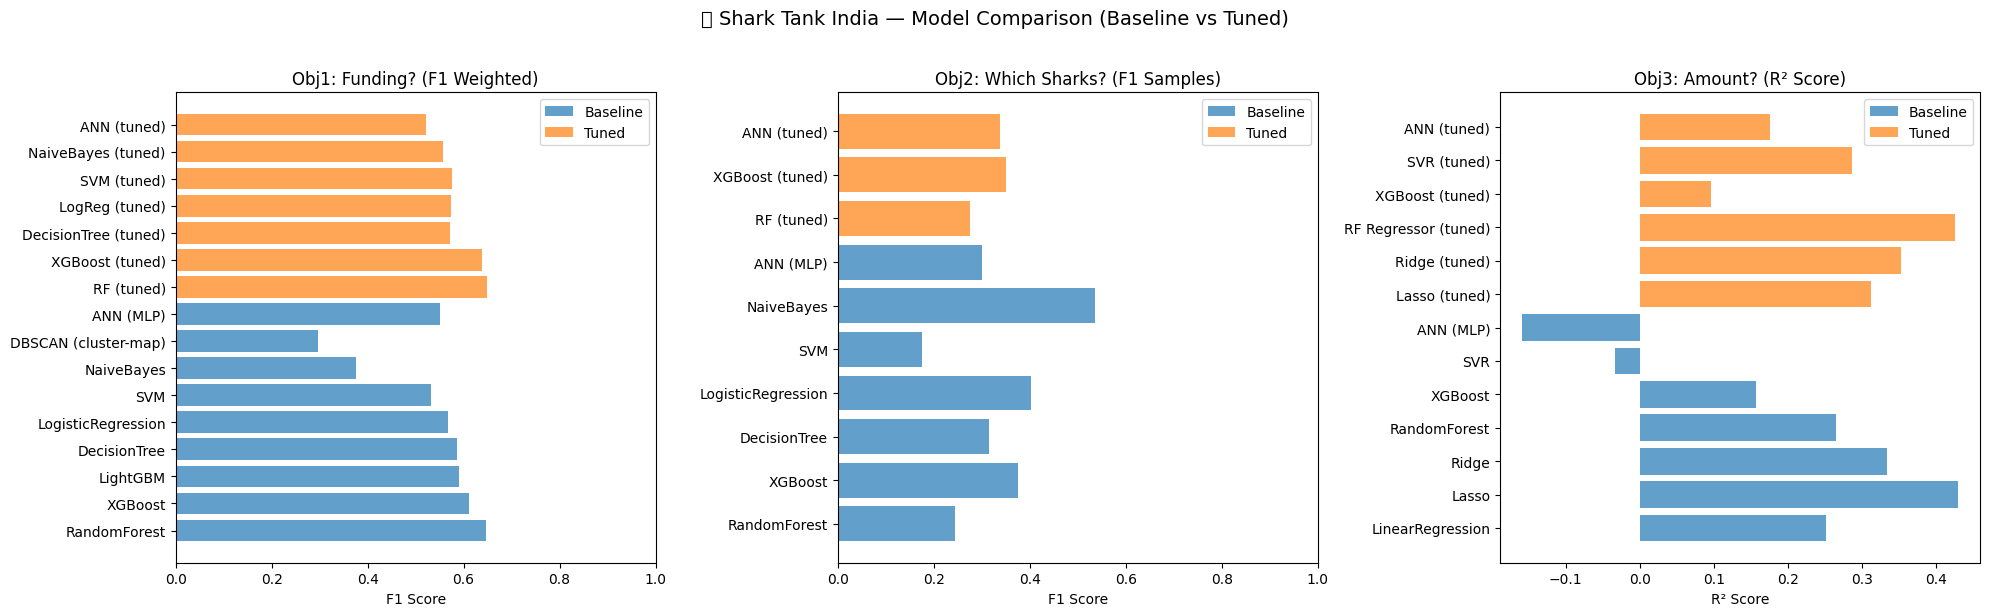

📊 Plot saved to shark_tank_results.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('🦈 Shark Tank India — Model Comparison (Baseline vs Tuned)', fontsize=14, y=1.02)

# Obj1
df1 = pd.concat([
    obj1_baseline_df[['model','f1']].assign(phase='Baseline'),
    obj1_tuned_df[['model','f1']].assign(phase='Tuned')
])
ax = axes[0]
for phase, grp in df1.groupby('phase'):
    ax.barh(grp['model'], grp['f1'], alpha=0.7, label=phase)
ax.set_title('Obj1: Funding? (F1 Weighted)')
ax.set_xlabel('F1 Score')
ax.legend()
ax.set_xlim(0, 1)

# Obj2
df2 = pd.concat([
    obj2_baseline_df[['model','f1_samples']].assign(phase='Baseline'),
    obj2_tuned_df[['model','f1_samples']].assign(phase='Tuned')
])
ax = axes[1]
for phase, grp in df2.groupby('phase'):
    ax.barh(grp['model'], grp['f1_samples'], alpha=0.7, label=phase)
ax.set_title('Obj2: Which Sharks? (F1 Samples)')
ax.set_xlabel('F1 Score')
ax.legend()
ax.set_xlim(0, 1)

# Obj3
df3 = pd.concat([
    obj3_baseline_df[['model','r2']].assign(phase='Baseline'),
    obj3_tuned_df[['model','r2']].assign(phase='Tuned')
])
ax = axes[2]
for phase, grp in df3.groupby('phase'):
    ax.barh(grp['model'], grp['r2'], alpha=0.7, label=phase)
ax.set_title('Obj3: Amount? (R² Score)')
ax.set_xlabel('R² Score')
ax.legend()

plt.tight_layout()
plt.savefig('shark_tank_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Plot saved to shark_tank_results.png')

In [21]:
print('\n' + '='*65)
print('🏆 BEST MODELS SUMMARY')
print('='*65)

best_obj1 = obj1_tuned_df.loc[obj1_tuned_df['f1'].idxmax()]
best_obj2 = obj2_tuned_df.loc[obj2_tuned_df['f1_samples'].idxmax()]
best_obj3 = obj3_tuned_df.loc[obj3_tuned_df['r2'].idxmax()]

print(f'\nObj1 (Binary — Funded?):    {best_obj1["model"]:30}  F1={best_obj1["f1"]:.4f}')
print(f'Obj2 (Multi-label — Who?):  {best_obj2["model"]:30}  F1-Samples={best_obj2["f1_samples"]:.4f}')
print(f'Obj3 (Regression — Amount): {best_obj3["model"]:30}  R2={best_obj3["r2"]:.4f}')


🏆 BEST MODELS SUMMARY

Obj1 (Binary — Funded?):    RF (tuned)                      F1=0.6478
Obj2 (Multi-label — Who?):  XGBoost (tuned)                 F1-Samples=0.3514
Obj3 (Regression — Amount): RF Regressor (tuned)            R2=0.4257


---
## 🔮 End-to-End Inference Pipeline
Use the best models from each stage to make predictions on new pitches.

In [22]:
def predict_pitch(X_new_raw: pd.DataFrame,
                  cls_model=best_rf_cls,
                  shark_model=best_rf_shark,
                  reg_model=best_rfr):
    """
    End-to-end prediction for new pitch(es).
    X_new_raw: raw (unscaled) feature DataFrame with same columns as training data.
    """
    X_new, _, _, _ = run_preprocessing(X_new_raw)

    # ── Align columns to match what the models were trained on ───────────────
    train_cols = cls_model.feature_names_in_
    X_new = X_new.reindex(columns=train_cols, fill_value=0)

    # Stage 1 — Funded?
    funded_pred = cls_model.predict(X_new)

    results = []
    for i, funded in enumerate(funded_pred):
        row = {'funded': bool(funded)}
        if not funded:
            row.update({'sharks': None, 'amount': None})
        else:
            xi = X_new.iloc[[i]]

            # Stage 2 — Which sharks?
            shark_cols = shark_model.feature_names_in_
            xi_shark = xi.reindex(columns=shark_cols, fill_value=0)
            shark_flags = shark_model.predict(xi_shark)[0]
            shark_names = ['Namita', 'Vineeta', 'Anupam', 'Aman', 'Peyush', 'Ritesh', 'Amit']
            sharks = [s for s, f in zip(shark_names, shark_flags) if f == 1]
            row['sharks'] = sharks if sharks else ['No specific shark predicted']

            # Stage 3 — How much?
            shark_df = pd.DataFrame([shark_flags], columns=[
                'Namita_Invested', 'Vineeta_Invested', 'Anupam_Invested',
                'Aman_Invested', 'Peyush_Invested', 'Ritesh_Invested', 'Amit_Invested'
            ])
            xi_aug = pd.concat([xi.reset_index(drop=True), shark_df], axis=1)
            reg_cols = reg_model.feature_names_in_
            xi_aug = xi_aug.reindex(columns=reg_cols, fill_value=0)
            row['amount'] = float(reg_model.predict(xi_aug)[0])

        results.append(row)

    return pd.DataFrame(results)


# ── Quick demo on test set ────────────────────────────────────────────────────
sample = raw_df.sample(n=10, random_state = 42).copy()
preds  = predict_pitch(sample)

# ── Build actuals from raw_df ─────────────────────────────────────────────────
shark_amt_cols = [
    'Namita Investment Amount', 'Vineeta Investment Amount',
    'Anupam Investment Amount', 'Aman Investment Amount',
    'Peyush Investment Amount', 'Ritesh Investment Amount',
    'Amit Investment Amount'
]
shark_names = ['Namita', 'Vineeta', 'Anupam', 'Aman', 'Peyush', 'Ritesh', 'Amit']

actual_funded = sample['Accepted Offer'].fillna(0).astype(int).tolist()
actual_amount = sample[shark_amt_cols].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1).tolist()
actual_sharks = [
    [name for name, col in zip(shark_names, shark_amt_cols)
     if pd.to_numeric(row[col], errors='coerce') > 0]
    for _, row in sample.iterrows()
]

# ── Side-by-side comparison ───────────────────────────────────────────────────
print('=' * 75)
print('ACTUAL vs PREDICTED — SAMPLE COMPARISON')
print('=' * 75)

for i in range(len(sample)):
    p = preds.iloc[i]
    print(f"\n── Pitch #{i+1} ──────────────────────────────────────────────────")

    # Funded
    a_f = bool(actual_funded[i])
    p_f = p['funded']
    match = '✅' if a_f == p_f else '❌'
    print(f"  Funded?   Actual: {str(a_f):<8}  Predicted: {str(p_f):<8}  {match}")

    # Sharks
    a_s = actual_sharks[i] if actual_sharks[i] else ['None']
    p_s = p['sharks'] if p['sharks'] is not None else ['None']
    match = '✅' if set(a_s) == set(p_s) else '❌'
    print(f"  Sharks    Actual: {', '.join(a_s):<30}  Predicted: {', '.join(p_s):<30}  {match}")

    # Amount
    a_a = actual_amount[i]
    p_a = p['amount'] if p['amount'] is not None else 0.0
    a_a_eff = a_a if a_a > 0 else None
    p_a = p['amount'] if p['amount'] is not None else float('nan')
    match = '✅' if (a_a == 0 and (p_a == 0 or pd.isna(p_a))) else ('✅' if (a_a > 0 and not pd.isna(p_a) and abs(a_a - p_a) / a_a < 0.25) else '❌')
    print(f"  Amount    Actual: ₹{a_a:<12.2f}  Predicted: ₹{p_a:<12.2f}  {match}")

print('\n' + '=' * 75)
print('RAW PREDICTIONS TABLE')
print('=' * 75)
print(preds.to_string())

⚠️  Warning: 20 NaN values remain in X. Filling with column medians.
ACTUAL vs PREDICTED — SAMPLE COMPARISON

── Pitch #1 ──────────────────────────────────────────────────
  Funded?   Actual: True      Predicted: True      ✅
  Sharks    Actual: Namita, Vineeta                 Predicted: Namita, Vineeta                 ✅
  Amount    Actual: ₹150.00        Predicted: ₹139.44        ✅

── Pitch #2 ──────────────────────────────────────────────────
  Funded?   Actual: False     Predicted: False     ✅
  Sharks    Actual: None                            Predicted: None                            ✅
  Amount    Actual: ₹0.00          Predicted: ₹nan           ✅

── Pitch #3 ──────────────────────────────────────────────────
  Funded?   Actual: False     Predicted: True      ❌
  Sharks    Actual: None                            Predicted: Anupam, Amit                    ❌
  Amount    Actual: ₹0.00          Predicted: ₹24.54         ❌

── Pitch #4 ───────────────────────────────────────────────

In [23]:
# Find rows where deal was accepted but no shark invested
funded_no_shark = raw_df[
    (raw_df['Accepted Offer'] == 1) &
    ((raw_df[shark_amt_cols].apply(pd.to_numeric, errors='coerce').fillna(0) > 0).sum(axis=1) == 0)
]

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

shark_present_cols = [
    'Namita Present', 'Vineeta Present', 'Anupam Present',
    'Aman Present', 'Peyush Present', 'Ritesh Present',
    'Amit Present', 'Guest Present'
]

display_cols = (
    ['Accepted Offer'] +
    shark_present_cols +
    shark_amt_cols
)

print(f"Rows funded but no shark invested: {len(funded_no_shark)}")

print(funded_no_shark[display_cols].to_string(index=True))

Rows funded but no shark invested: 0
Empty DataFrame
Columns: [Accepted Offer, Namita Present, Vineeta Present, Anupam Present, Aman Present, Peyush Present, Ritesh Present, Amit Present, Guest Present, Namita Investment Amount, Vineeta Investment Amount, Anupam Investment Amount, Aman Investment Amount, Peyush Investment Amount, Ritesh Investment Amount, Amit Investment Amount]
Index: []
